In [1]:
import os
if os.getcwd()[-11:] == "exploration":
    os.chdir('..')
import data.involcan.pull

### Find sensors of interest

In [2]:
import pandas as pd

files = pd.read_csv("data/involcan/metadata/available_files.csv")

In [3]:
# from datetime import datetime
starttime = pd.Timestamp('2021-09-12', tz='UTC')
endtime = pd.Timestamp('2021-09-26', tz='UTC')

files['start_time'] = pd.to_datetime(files['start_time'], utc=True)
files['end_time'] = pd.to_datetime(files['end_time'], utc=True)


eruption_files = files[(files['start_time']==starttime) | (files['end_time']==endtime) ]
eruption_sensors = pd.unique(eruption_files['sensor']).tolist()

In [4]:
print(f"There were {len(eruption_sensors)} measuring during the eruption")
print(f"They were: \n {eruption_sensors}")

There were 18 measuring during the eruption
They were: 
 ['PGAR', 'PBBA', 'PPMA', 'PMLU', 'PLPI', 'PTAB', 'PCOR', 'PA03', 'PA00', 'PA05', 'PA09', 'PA01', 'PA04', 'PA02', 'PA08', 'PA06', 'PA07', 'PSAB']


In [5]:
sensors = pd.read_csv("data/involcan/metadata/stations_all.dat", sep=r"\s+",names=["station", "lat", "lon", "height"])
sensors_lp = sensors[
    ((sensors['lat']<28.871164) & (sensors['lat']>28.437932)) &
    ((sensors['lon']<-17.666590) & (sensors['lon']>-18.039439))
]


### Download the files of interest

In [6]:
from datetime import datetime, timedelta
starttime = datetime(2021, 9, 15)
endtime = datetime(2021, 9, 20)
# endtime = datetime(2021, 12, 14)
data_path = "/SCRATCH/TIC270/dvalesp/data/involcan/mseed/"
channels = ["HHE", "HHN", "HHZ"]
channels = ["HHE"]
sensors = eruption_sensors

# data.involcan.pull.download_files(starttime, endtime, sensors, channels, data_path, user='seiscomp', verbose=True);

#### Discarded sensors:
- PGAR: File missing data
- PBBA: File missing data
- PA03: Missing data before the 18th of september
- PA00: Missing data before the 19th of september
- PA05: Missing data in the period of interest
- PA09: Missing data in the period of interest
- PA01: Missing data in the period of interest
- PA04: Missing data in the period of interest
- PA02: Missing data in the period of interest
- PA08: Missing data in the period of interest
- PA06: Missing data in the period of interest
- PA07: Missing data in the period of interest
- PSAB: No data in the period of interest


### Analyze the data

Reading 2021 data for sensor PPMA...


/home/TIC270/gsus/DigiVolcan/installation/miniconda3/envs/lafragua/lib/python3.12/site-packages/obspy/io/mseed/util.py:758: UserWarning: Inconsistent word order.
  warnings.warn(msg, UserWarning)


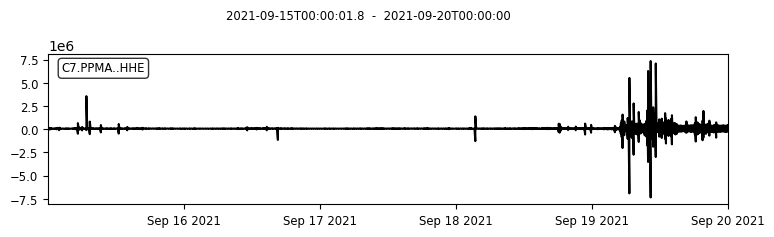

Reading 2021 data for sensor PMLU...


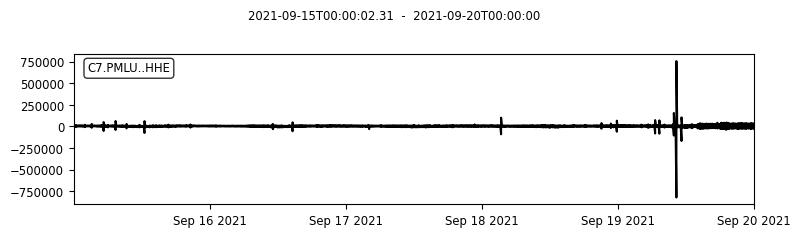

Reading 2021 data for sensor PCOR...


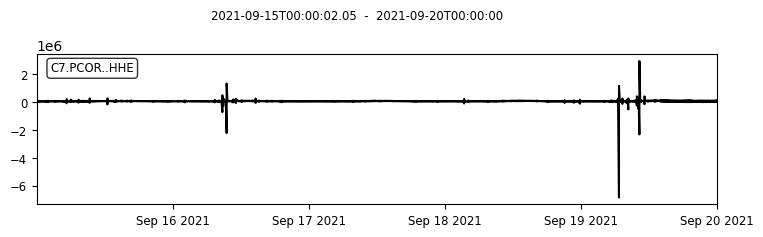

In [7]:
import obspy
from obspy.core import UTCDateTime

ST = []
sensors = ['PPMA', 'PMLU', 'PCOR']
# sensors = ['PPMA']

sensor_ids = [eruption_sensors.index(element) for element in sensors if element in eruption_sensors]

for sensor_id in sensor_ids:
    print(f"Reading 2021 data for sensor {eruption_sensors[sensor_id]}...")
    st = obspy.read(f"{data_path}/C7.{eruption_sensors[sensor_id]}.*.2021.*",
                    starttime=UTCDateTime(starttime), endtime=UTCDateTime(endtime))
    st.merge()
    st.plot();
    ST.append(st)



In [8]:
ST

[1 Trace(s) in Stream:
C7.PPMA..HHE | 2021-09-15T00:00:01.800000Z - 2021-09-20T00:00:00.000000Z | 100.0 Hz, 43199821 samples,
 1 Trace(s) in Stream:
C7.PMLU..HHE | 2021-09-15T00:00:02.310000Z - 2021-09-20T00:00:00.000000Z | 100.0 Hz, 43199770 samples,
 1 Trace(s) in Stream:
C7.PCOR..HHE | 2021-09-15T00:00:02.050000Z - 2021-09-20T00:00:00.000000Z | 100.0 Hz, 43199796 samples]

#### Analyze frequencies with MESA

In [9]:
from msa.feature_extraction import features
from msa.visualization import plot

In [10]:
sr = st[0].stats.sampling_rate

window_length = 18 # s
window_samples = int(window_length*sr)
# shift = window_length*1000 #s
shift = 3600 #s
hop = int(shift*sr)

M = len(sensor_ids)
times = [[] for _ in range(M)]
freqs = [[] for _ in range(M)]
Sxxs  = [[] for _ in range(M)]

for i, sensor_id in enumerate(sensor_ids):

    signal = ST[i][0].data
    time, freq, Sxx = features.spectrogram(signal, sr, window_samples, hop, "blackman", "zeros", "linear",)
    times[i] = time[1:]
    freqs[i] = freq
    Sxxs[i]  = Sxx[:,1:]

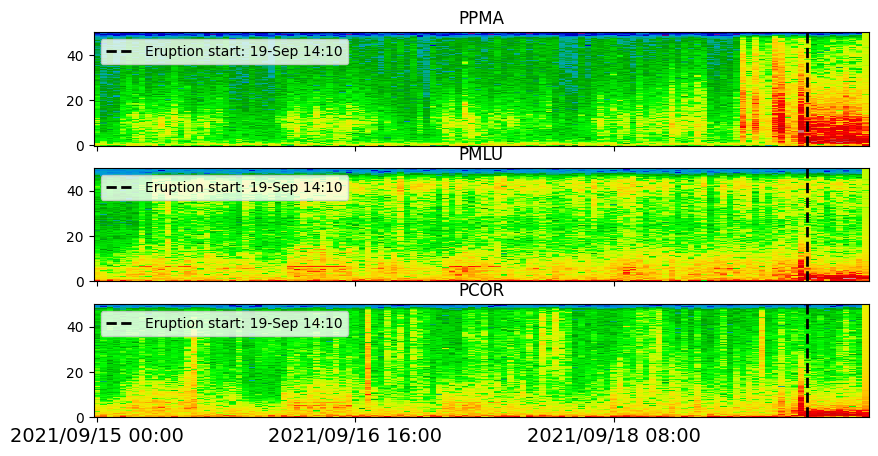

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# timeUTC = np.linspace(starttime, endtime, num= len(times), endpoint=False, dtype='datetime64[s]')#.astype("datetime64[m]")
timeUTC = np.arange(starttime, endtime, timedelta(seconds=shift), dtype='datetime64[s]')#.astype("datetime64[m]")

target_time = np.datetime64(datetime(2021, 9, 19, 14, 10), 'm')
eruption_idx = np.argmin(np.abs(timeUTC - target_time))

fig, ax = plt.subplots(M,1, figsize=(10,5), sharex=True)
if type(ax) != np.ndarray: ax = [ax]

skip:int = len(times[0])//3
locs = times[0][0::skip]
timeUTC_label = timeUTC[0::skip]
date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]

for i, sensor_id in enumerate(sensor_ids):
    ax[i].set_title(f"{eruption_sensors[sensor_id]}")
    plot.spectrogram(times[i], freqs[i], Sxxs[i], cmap="nipy_spectral", logscale=True, ax = ax[i]);

    ax[i].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);
    # ax.set_ylabel("Frequency (Hz)", fontsize=20)

    ax[i].axvline(x=times[i][eruption_idx], color='black', linestyle='--', linewidth=2, label='Eruption start: 19-Sep 14:10')
    ax[i].legend();

### PCA Visualizations

In [12]:
# Data fusion
X = np.vstack(Sxxs).T

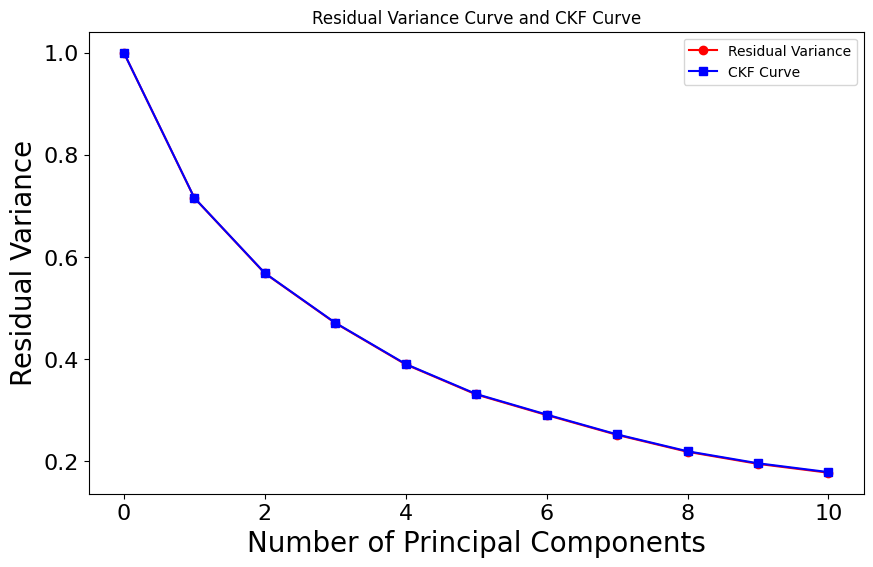

In [13]:
import mspc_pca.plot
mspc_pca.plot.var_pca(X, 10);

In [14]:
# !pip install scikit-learn

In [15]:
from sklearn.decomposition import PCA
PCs=1
pca = PCA(n_components=PCs)
# mspc_pca.plot.biplot(X, pca, 1, 2, times[0], np.round(freq, 2), score_classes=times[0]);

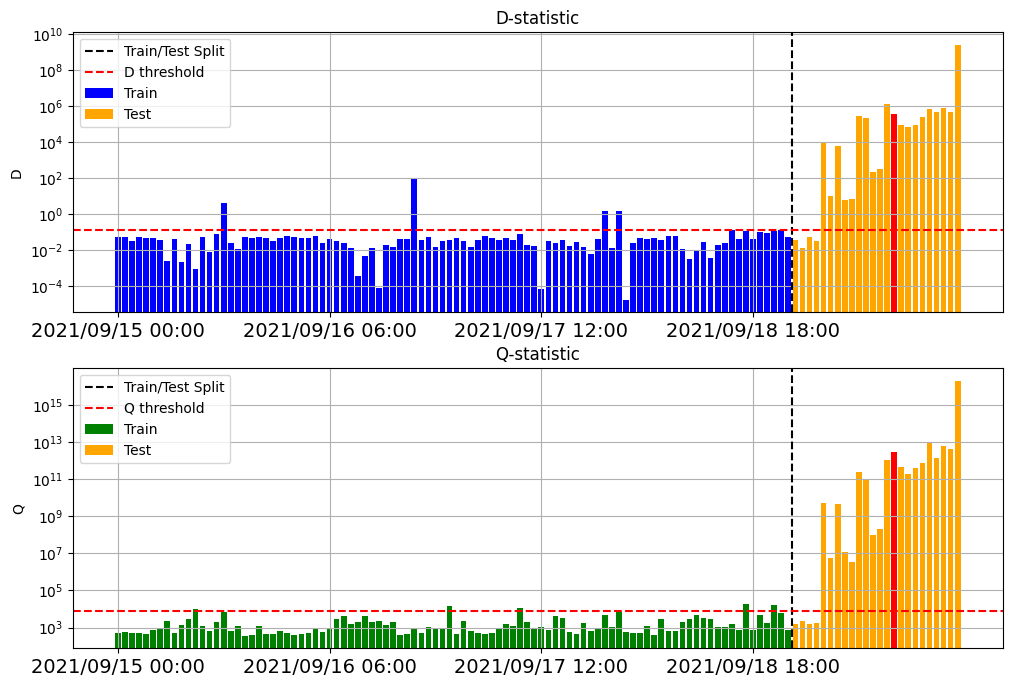

In [16]:
import mspc_pca.mspc

day_id = np.argmin(np.abs(timeUTC - np.datetime64(datetime(2021, 9, 19), 'm')))

D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q = mspc_pca.mspc.DQ_tt(X[:day_id], X[day_id:], PCs, percentile_threshold=True, alpha=0.05)

fig, ax = mspc_pca.mspc.plot_DQ_tt(D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q,
                                   logscale=True, event_index=[eruption_idx], 
                labels=None, plot_train=True, opacity=None, ax=None)

skip:int = len(timeUTC)//4
locs = np.arange(0, len(timeUTC))[0::skip]
timeUTC_label = timeUTC[0::skip]
date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]
ax[0].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);
ax[1].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);

#### oMEDA

In [17]:
X_copy = X.copy()

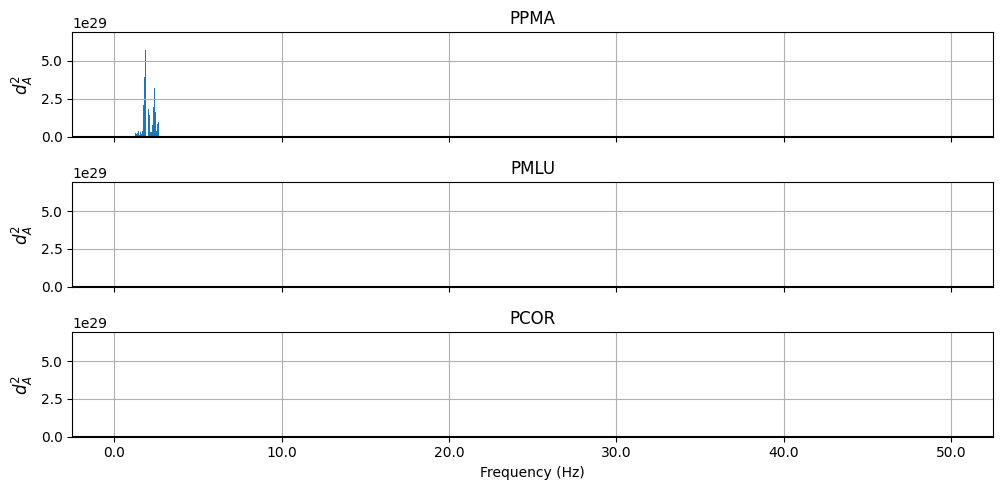

In [18]:
from mspc_pca.omeda import omeda
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

preprocessing = 1
n_components = 2
logscale = False

# Frequency labels
n_freq = X.shape[1] // len(sensor_ids)
var_labels = np.linspace(0, sr // 2, n_freq)
var_label_ids = [i for i, label in enumerate(var_labels) if label % 10 == 0]
var_labels_str = [str(round(label, 4)) for label in var_labels if label % 10 == 0]
var_classes = []

# Scale
with_mean = True if preprocessing == 1 or preprocessing == 2 else False
with_std = True if preprocessing == 2 else False
scaler = StandardScaler(with_mean=with_mean, with_std=with_std)
X_norm = scaler.fit_transform(X)

# PCA
pca_model = PCA(n_components=n_components)
scores = pca_model.fit_transform(X_norm)
loadings = pca_model.components_.T

dummy = - np.ones(len(X))
dummy[:eruption_idx] = 1

dummy = -dummy


omeda_vec = omeda(testcs=X_norm, dummy=dummy, R=loadings, plot=False)

fig, ax = plt.subplots(len(sensor_ids),1, figsize=(10,5), sharex=True)
if type(ax) != np.ndarray: ax = [ax]

for i, sensor_id in enumerate(sensor_ids):
    x = np.arange(len(omeda_vec[i*n_freq : (i+1)*n_freq]))

    # Handle coloring
    if var_classes:
        unique_classes = np.unique(var_classes)
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i % 10) for i in range(len(unique_classes))]
        class_color_map = dict(zip(unique_classes, colors))
        bar_colors = [class_color_map[cls] for cls in var_classes]

        # Create legend
        patches = [mpatches.Patch(color=color, label=str(cls)) for cls, color in class_color_map.items()]
        ax[i].legend(handles=patches, prop={'size': 10})
    else:
        bar_colors = 'tab:blue'

    ax[i].bar(x, omeda_vec[i*n_freq : (i+1)*n_freq], color=bar_colors)

    ax[i].axhline(0, color='black', linewidth=1.5)  # X-axis

    # Handle variable labels
    if len(var_labels_str) > 0:
        ax[i].set_xticks(var_label_ids)
        label_lengths = [len(str(label)) for label in var_labels]
        rot = 90 if max(label_lengths) > 20 else 0  # rotate if labels are too long
        ax[i].set_xticklabels(var_labels_str, rotation=rot)
        ax[i].tick_params(axis='x', labelsize=10)

    ax[i].set_title(f"{eruption_sensors[sensor_id]}")
    if i == len(sensor_ids) - 1:
        ax[i].set_xlabel("Frequency (Hz)")
    ax[i].set_ylabel('$d^2_A$', fontsize=12)
    ax[i].grid(True)
    # ax[i].set_xlim(0, )
    if logscale:
        ax[i].set_yscale("log")
        ax[i].set_ylim(1, 100 * max(omeda_vec))
    else:
        ax[i].set_ylim(0.8 * min(omeda_vec), 1.2 * max(omeda_vec))

plt.tight_layout()
plt.show()

In [19]:
np.isclose(X,X_copy)

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(120, 2703))

In [120]:
from scipy.io import savemat

tosave = {'X':X, 'var_labels':var_labels, 'omeda_mc':omeda_vec}

savemat("jobs/features_mc.mat",tosave)

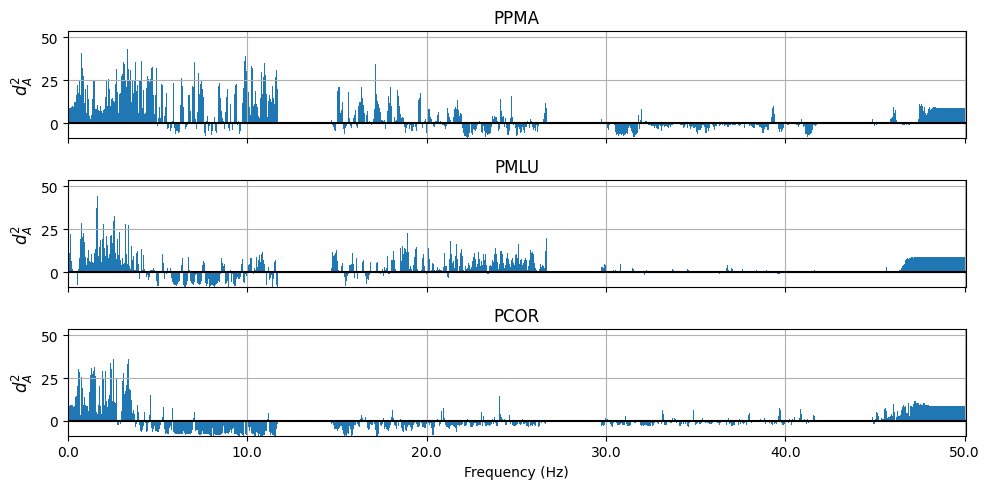

In [ ]:
from mspc_pca.omeda import omeda
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

preprocessing = 2
n_components = 2
logscale = False

# Frequency labels
n_freq = X.shape[1] // len(sensor_ids)
var_labels = np.linspace(0, sr // 2, n_freq)
var_label_ids = [i for i, label in enumerate(var_labels) if label % 10 == 0]
var_labels_str = [str(round(label, 4)) for label in var_labels if label % 10 == 0]
var_classes = []

# Scale
with_mean = True if preprocessing == 1 or preprocessing == 2 else False
with_std = True if preprocessing == 2 else False
scaler = StandardScaler(with_mean=with_mean, with_std=with_std)
X_norm = scaler.fit_transform(X)

# PCA
pca_model = PCA(n_components=n_components)
scores = pca_model.fit_transform(X_norm)
loadings = pca_model.components_.T

dummy = - np.ones(len(X))
dummy[:eruption_idx] = 1

dummy = -dummy


omeda_vec = omeda(testcs=X_norm, dummy=dummy, R=loadings, plot=False)

fig, ax = plt.subplots(len(sensor_ids),1, figsize=(10,5), sharex=True)
if type(ax) != np.ndarray: ax = [ax]

for i, sensor_id in enumerate(sensor_ids):
    x = np.arange(len(omeda_vec[i*n_freq : (i+1)*n_freq]))

    # Handle coloring
    if var_classes:
        unique_classes = np.unique(var_classes)
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i % 10) for i in range(len(unique_classes))]
        class_color_map = dict(zip(unique_classes, colors))
        bar_colors = [class_color_map[cls] for cls in var_classes]

        # Create legend
        patches = [mpatches.Patch(color=color, label=str(cls)) for cls, color in class_color_map.items()]
        ax[i].legend(handles=patches, prop={'size': 10})
    else:
        bar_colors = 'tab:blue'

    ax[i].bar(x, omeda_vec[i*n_freq : (i+1)*n_freq], color=bar_colors)

    ax[i].axhline(0, color='black', linewidth=1.5)  # X-axis

    # Handle variable labels
    if len(var_labels_str) > 0:
        ax[i].set_xticks(var_label_ids)
        label_lengths = [len(str(label)) for label in var_labels]
        rot = 90 if max(label_lengths) > 20 else 0  # rotate if labels are too long
        ax[i].set_xticklabels(var_labels_str, rotation=rot)
        ax[i].tick_params(axis='x', labelsize=10)

    ax[i].set_title(f"{eruption_sensors[sensor_id]}")
    if i == len(sensor_ids) - 1:
        ax[i].set_xlabel("Frequency (Hz)")
    ax[i].set_ylabel('$d^2_A$', fontsize=12)
    ax[i].grid(True)
    ax[i].set_xlim(0, n_freq)
    if logscale:
        ax[i].set_yscale("log")
        ax[i].set_ylim(1, 100 * max(omeda_vec))
    else:
        ax[i].set_ylim(0.8 * min(omeda_vec), 1.2 * max(omeda_vec))

plt.tight_layout()
plt.show()

In [122]:
from scipy.io import savemat

tosave = {'X':X, 'var_labels':var_labels, 'omeda_as':omeda_vec}

savemat("jobs/features_as.mat",tosave)

In [ ]:
eruption_idx

np.int64(110)